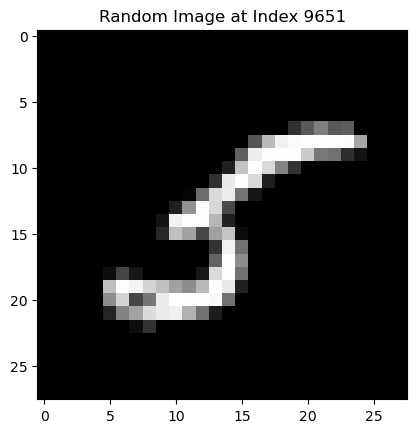

In [17]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()


In [18]:
def erosion(image, se):
    img_h, img_w = image.shape
    se_h, se_w = se.shape
    se_center_h, se_center_w = se_h // 2, se_w // 2

    eroded_image = np.full_like(image, 255)

    for i in range(se_center_h, img_h - se_center_h):
        for j in range(se_center_w, img_w - se_center_w):
            local_min = 255
            for k in range(se_h):
                for l in range(se_w):
                    if se[k, l] == 1:
                        local_min = min(local_min, image[i - se_center_h + k, j - se_center_w + l])
            eroded_image[i, j] = local_min

    return eroded_image

In [19]:
def dilation(image, se):
    img_h, img_w = image.shape
    se_h, se_w = se.shape
    se_center_h, se_center_w = se_h // 2, se_w // 2

    dilated_image = np.full_like(image, 0)

    for i in range(se_center_h, img_h - se_center_h):
        for j in range(se_center_w, img_w - se_center_w):
            local_max = 0
            for k in range(se_h):
                for l in range(se_w):
                    if se[k, l] == 1:
                        local_max = max(local_max, image[i - se_center_h + k, j - se_center_w + l])
            dilated_image[i, j] = local_max

    return dilated_image

In [20]:
def opening(image, se):
    return dilation(erosion(image, se), se)

In [21]:
def closing(image, se):
    return erosion(dilation(image, se), se)

In [22]:
def hit_and_miss(image, se1, se2):
    eroded1 = erosion(image, se1)
    eroded2 = erosion(255 - image, se2)
    return np.where(eroded1 == 0, 0, eroded2)

In [23]:
se = np.array([[0, 1, 0],
               [1, 1, 1],
               [0, 1, 0]], dtype=np.uint8)

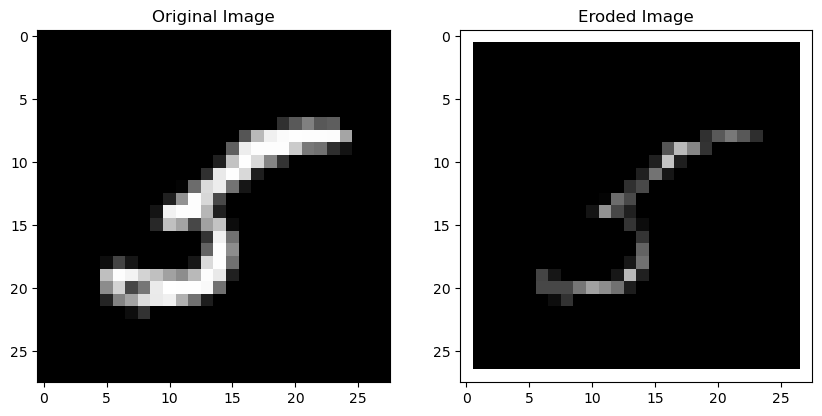

In [24]:
eroded_image = erosion(random_image, se)

plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(random_image, cmap='gray')

# Eroded Image
plt.subplot(1, 2, 2)
plt.title("Eroded Image")
plt.imshow(eroded_image, cmap='gray')

plt.show()

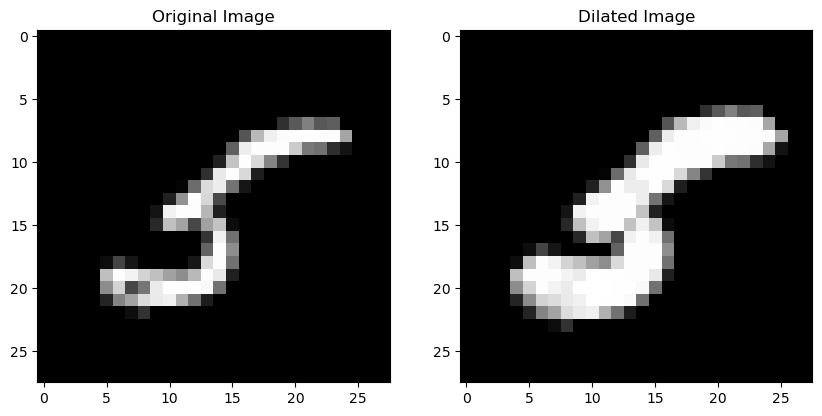

In [25]:
dilated_image = dilation(random_image, se)

plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(random_image, cmap='gray')

# Dilated Image
plt.subplot(1, 2, 2)
plt.title("Dilated Image")
plt.imshow(dilated_image, cmap='gray')

plt.show()

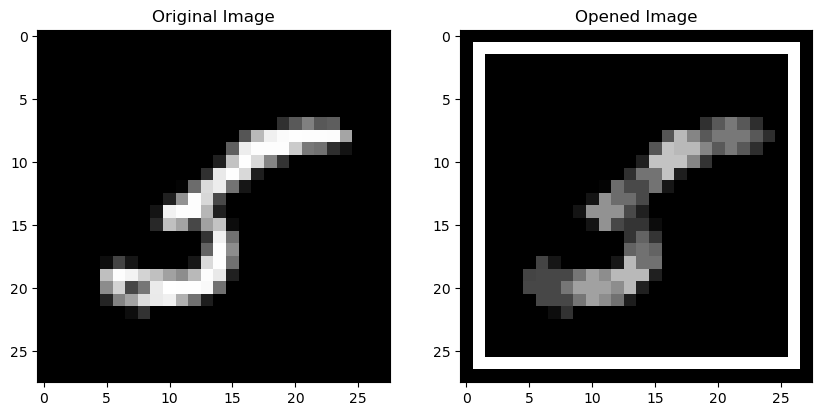

In [26]:
opened_image = opening(random_image, se)

# Original Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(random_image, cmap='gray')

# Opened Image
plt.subplot(1, 2, 2)
plt.title("Opened Image")
plt.imshow(opened_image, cmap='gray')

plt.show()

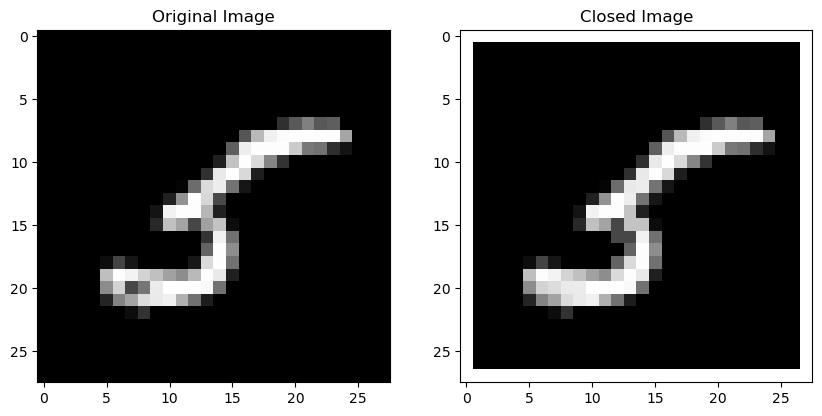

In [27]:
closed_image = closing(random_image, se)

# Original Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(random_image, cmap='gray')

# Closed Image
plt.subplot(1, 2, 2)
plt.title("Closed Image")
plt.imshow(closed_image, cmap='gray')

plt.show()

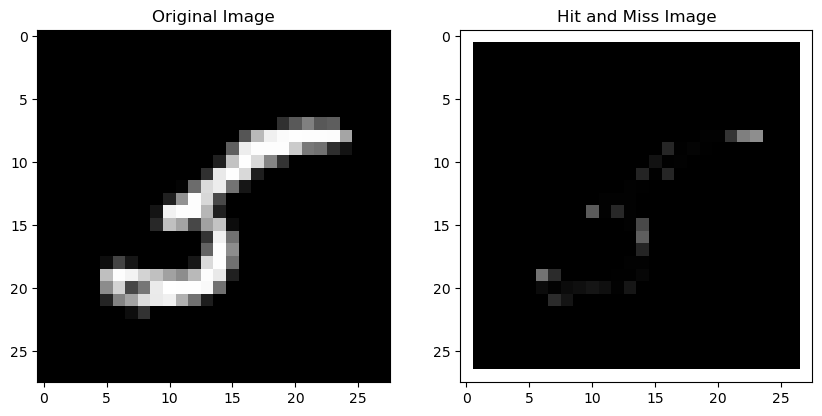

In [28]:

se2 = 1 - se
hit_miss_image = hit_and_miss(random_image, se, se2)

# Original Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(random_image, cmap='gray')

# Hit and Miss Image
plt.subplot(1, 2, 2)
plt.title("Hit and Miss Image")
plt.imshow(hit_miss_image, cmap='gray')

plt.show()